In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df=pd.read_csv("cleaned_netflix_titles.csv")
print("file loaded")


file loaded


C:\Users\mmpat\AppData\Local\Temp\ipykernel_21444\4175675519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set1')


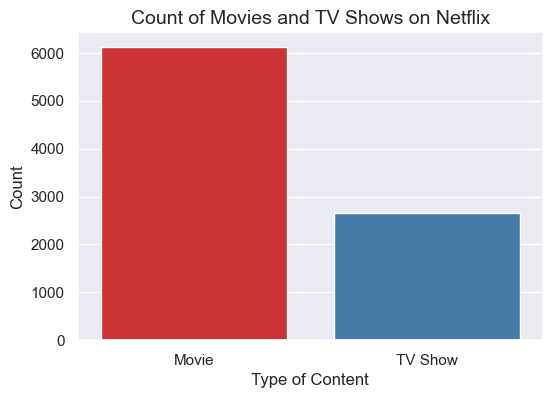

In [3]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette='Set1')
plt.title('Count of Movies and TV Shows on Netflix',fontsize=14)
plt.xlabel('Type of Content',fontsize=12)
plt.ylabel('Count',fontsize=12)
plt.show()

In [4]:
plt.figure(figsize=(10, 6))
top_countries = df['country'].value_counts().head(10).reset_index()
top_countries.columns=["country","count"]
top_countries.index+=1
print(top_countries)

           country  count
1    United States   2809
2            India    972
3          Unknown    830
4   United Kingdom    418
5            Japan    244
6      South Korea    199
7           Canada    181
8            Spain    145
9           France    124
10          Mexico    110


<Figure size 1000x600 with 0 Axes>

C:\Users\mmpat\AppData\Local\Temp\ipykernel_21444\2192828648.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries,x="count",y="country",palette="Set2",orient="h")


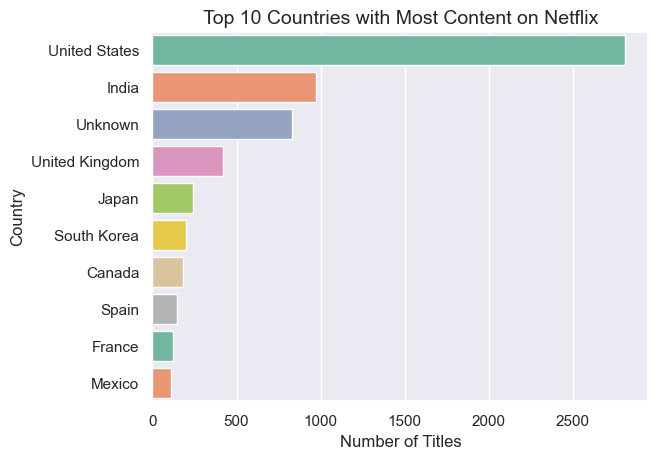

In [5]:
sns.barplot(data=top_countries,x="count",y="country",palette="Set2",orient="h")
plt.title('Top 10 Countries with Most Content on Netflix',fontsize=14)
plt.xlabel('Number of Titles',fontsize=12)
plt.ylabel('Country',fontsize=12)
plt.show()

In [6]:
print(df.rating)

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8789        R
8790    TV-Y7
8791        R
8792       PG
8793    TV-14
Name: rating, Length: 8794, dtype: object


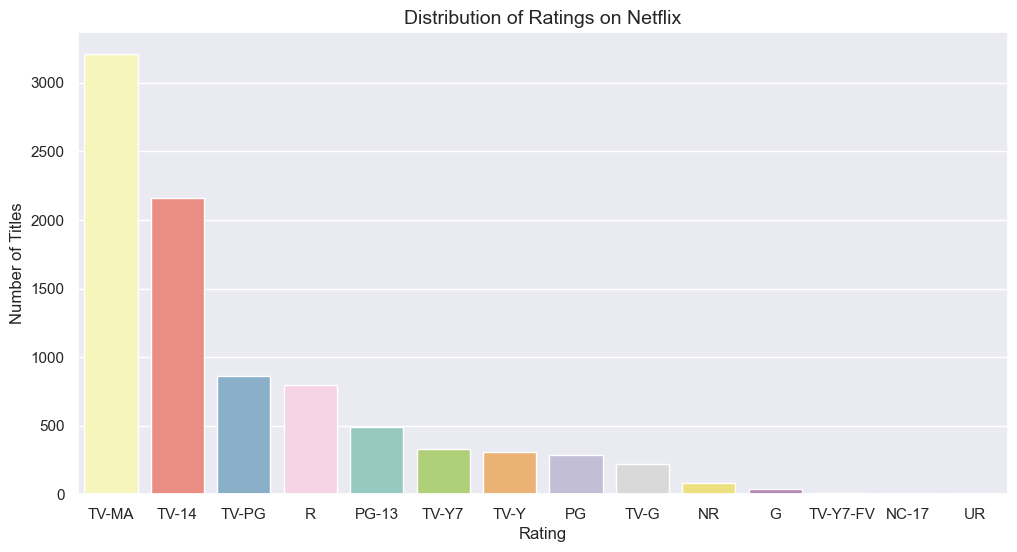

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df,x='rating',order=df['rating'].value_counts().index,hue='rating',legend=False,palette='Set3')
plt.title('Distribution of Ratings on Netflix',fontsize=14)
plt.xlabel('Rating',fontsize=12)
plt.ylabel('Number of Titles',fontsize=12)
plt.show()

In [8]:
print(df.date_added)

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8789     November 20, 2019
8790          July 1, 2019
8791      November 1, 2019
8792      January 11, 2020
8793         March 2, 2019
Name: date_added, Length: 8794, dtype: object


In [9]:
print(df[['date_added','release_year']].head(30))

            date_added  release_year
0   September 25, 2021          2020
1   September 24, 2021          2021
2   September 24, 2021          2021
3   September 24, 2021          2021
4   September 24, 2021          2021
5   September 24, 2021          2021
6   September 24, 2021          2021
7   September 24, 2021          1993
8   September 24, 2021          2021
9   September 24, 2021          2021
10  September 24, 2021          2021
11  September 23, 2021          2021
12  September 23, 2021          2021
13  September 22, 2021          2021
14  September 22, 2021          2021
15  September 22, 2021          2021
16  September 22, 2021          2020
17  September 22, 2021          2020
18  September 22, 2021          2021
19  September 22, 2021          2021
20  September 22, 2021          2021
21  September 22, 2021          2018
22  September 21, 2021          1996
23  September 21, 2021          2021
24  September 21, 2021          1998
25  September 21, 2021          2021
2

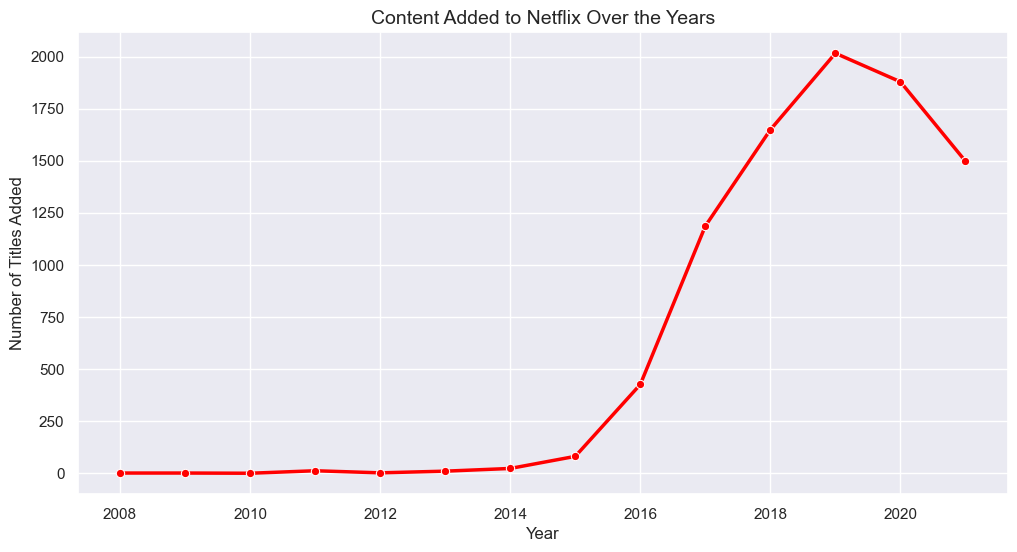

In [10]:

df["year_added"] = pd.to_datetime(df["date_added"].str.strip()).dt.year
yearly_counts = df["year_added"].value_counts().sort_index().reset_index()
yearly_counts.columns = ["year", "count"]

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_counts,
    x="year",
    y="count",
    marker="o",
    color="red",
    linewidth=2.5,
)

plt.title("Content Added to Netflix Over the Years", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Titles Added", fontsize=12)

plt.show()

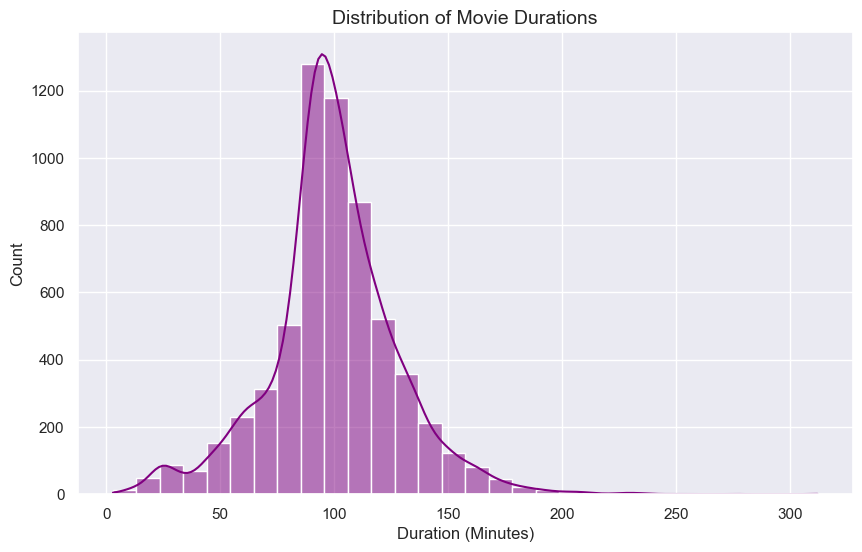

In [11]:
# Filter the dataset to only include Movies and clean the duration column to be numeric
movies_df = df[df["type"] == "Movie"].copy()
movies_df["duration_int"] = (
    movies_df["duration"].str.replace(" min", "").astype(float)
)

plt.figure(figsize=(10, 6))
sns.histplot(
    movies_df["duration_int"], bins=30, kde=True, color="purple"
)

plt.title("Distribution of Movie Durations", fontsize=14)
plt.xlabel("Duration (Minutes)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

In [12]:
print(df[['cast']].head(10))

                                                cast
0                                            Unknown
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
3                                            Unknown
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
5  Kate Siegel, Zach Gilford, Hamish Linklater, H...
6  Vanessa Hudgens, Kimiko Glenn, James Marsden, ...
7  Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...
8  Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...
9  Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...


C:\Users\mmpat\AppData\Local\Temp\ipykernel_21444\3593884653.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cast, x="count", y="actor", palette="magma")


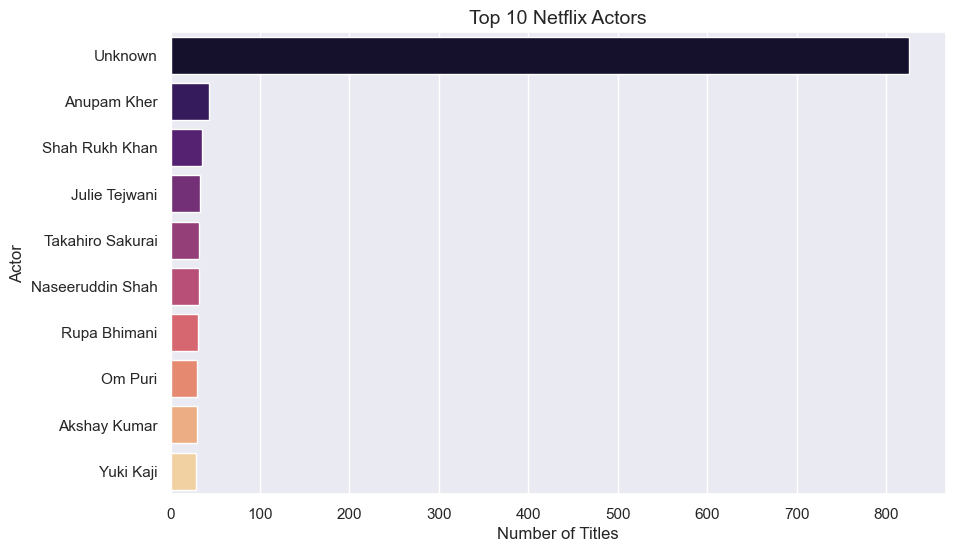

In [ ]:
cast_df = (
    df["cast"].dropna().str.split(", ").explode().reset_index(drop=True)
)
top_cast = cast_df.value_counts().head(10).reset_index()
top_cast.columns = ["actor", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_cast, x="count", y="actor", palette="magma")

plt.title("Top 10 Netflix Actors", fontsize=14)
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Actor", fontsize=12)

plt.show()

In [23]:
print(df[['date_added','type']].head(30).reset_index(drop=True))   

            date_added     type
0   September 25, 2021    Movie
1   September 24, 2021  TV Show
2   September 24, 2021  TV Show
3   September 24, 2021  TV Show
4   September 24, 2021  TV Show
5   September 24, 2021  TV Show
6   September 24, 2021    Movie
7   September 24, 2021    Movie
8   September 24, 2021  TV Show
9   September 24, 2021    Movie
10  September 24, 2021  TV Show
11  September 23, 2021  TV Show
12  September 23, 2021    Movie
13  September 22, 2021    Movie
14  September 22, 2021  TV Show
15  September 22, 2021  TV Show
16  September 22, 2021    Movie
17  September 22, 2021  TV Show
18  September 22, 2021    Movie
19  September 22, 2021  TV Show
20  September 22, 2021  TV Show
21  September 22, 2021  TV Show
22  September 21, 2021    Movie
23  September 21, 2021    Movie
24  September 21, 2021    Movie
25  September 21, 2021  TV Show
26  September 21, 2021    Movie
27  September 20, 2021    Movie
28  September 19, 2021    Movie
29  September 19, 2021    Movie


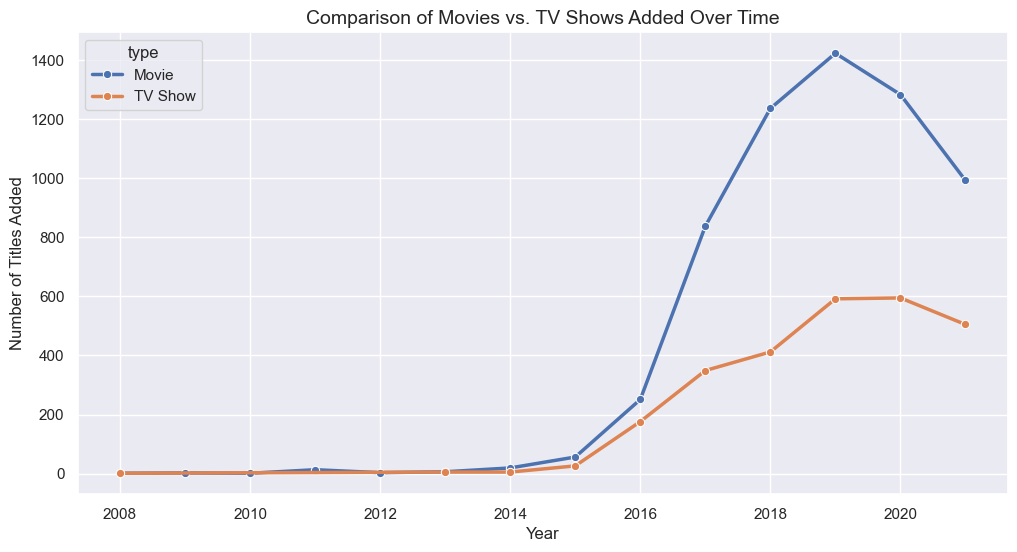

In [ ]:

df["year_added"] = pd.to_datetime(df["date_added"].str.strip()).dt.year
time_df = df.dropna(subset=["year_added"])


yearly_type = (
    time_df.groupby(["year_added", "type"]).size().reset_index(name="count")
)

plt.figure(figsize=(12, 6))


sns.lineplot(
    data=yearly_type,
    x="year_added",
    y="count",
    hue="type",
    marker="o",
    linewidth=2.5,
)

plt.title("Comparison of Movies vs. TV Shows Added Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Titles Added", fontsize=12)

plt.show()